In [1]:
from google.colab import files
uploaded = files.upload()



Saving traffic.csv to traffic.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [3]:
df = pd.read_csv('traffic.csv')
df.head()


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [4]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [5]:
df.isnull().sum()


,0
DateTime,0
Junction,0
Vehicles,0
ID,0


In [6]:
df = df.dropna()


In [8]:
print(df.columns)


Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')


In [9]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day
df['Month'] = df['DateTime'].dt.month
df['DayOfWeek'] = df['DateTime'].dt.dayofweek

df.head()


,DateTime,Junction,Vehicles,ID,Hour,Day,Month,DayOfWeek
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,6
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,6
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,6


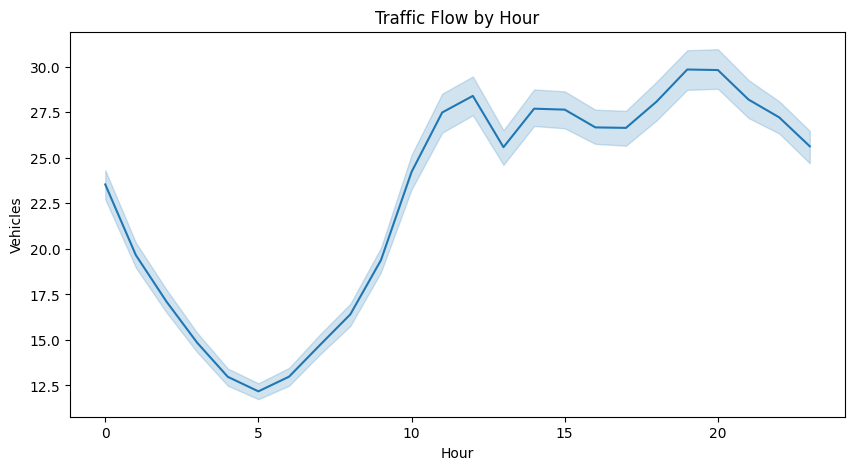

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(x=df['Hour'], y=df['Vehicles'])
plt.title("Traffic Flow by Hour")
plt.xlabel("Hour")
plt.ylabel("Vehicles")
plt.show()


In [11]:
X = df[['Junction', 'Hour', 'Day', 'Month', 'DayOfWeek']]
y = df['Vehicles']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)


RandomForestRegressor()

In [14]:
predictions = model.predict(X_test)

print(predictions[:10])


[ 7.49 59.04  7.05 10.79 18.36 13.43  6.76 14.41 14.18 23.71]


In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)


MAE: 4.688194098088113
R2 Score: 0.8671321388818798


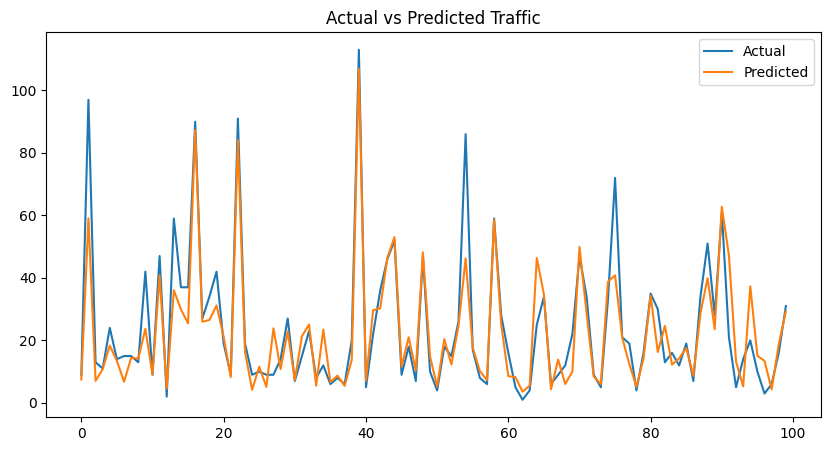

In [16]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Traffic")
plt.show()


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)


Mean Absolute Error: 4.688194098088113
Root Mean Squared Error: 7.3586591287340575
R2 Score: 0.8671321388818798


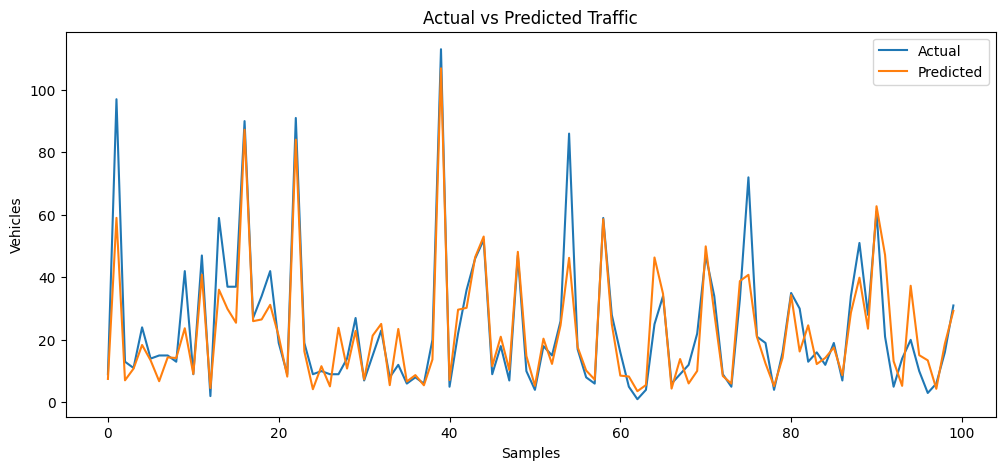

In [19]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(predictions[:100], label="Predicted")
plt.title("Actual vs Predicted Traffic")
plt.xlabel("Samples")
plt.ylabel("Vehicles")
plt.legend()
plt.show()


In [21]:
sample_input = [[2, 8, 15, 3, 1]]
# Junction=2, Hour=8, Day=15, Month=3, DayOfWeek=1

predicted_traffic = model.predict(sample_input)

print("Predicted Vehicles:", predicted_traffic[0])


Predicted Vehicles: 14.73


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


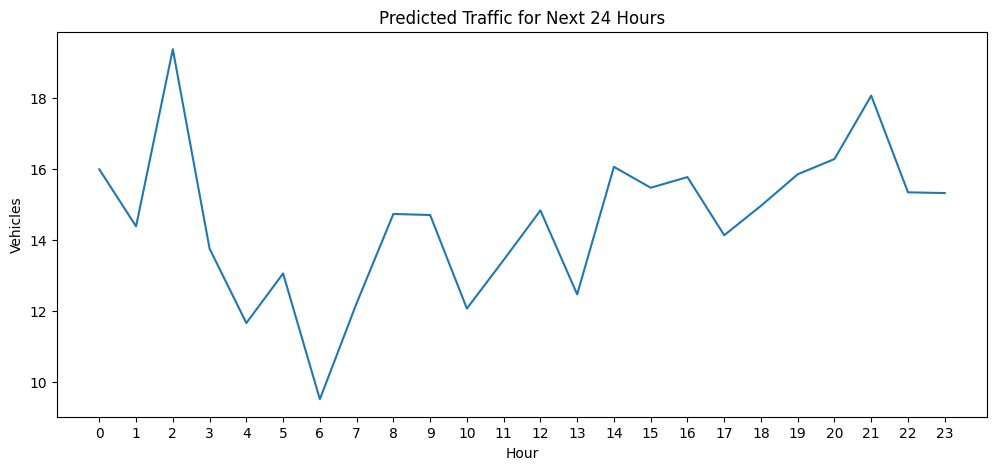

In [22]:
future_hours = pd.DataFrame({
    'Junction': [2]*24,
    'Hour': list(range(24)),
    'Day': [15]*24,
    'Month': [3]*24,
    'DayOfWeek': [1]*24
})

future_predictions = model.predict(future_hours)

plt.figure(figsize=(12,5))
plt.plot(range(24), future_predictions)
plt.title("Predicted Traffic for Next 24 Hours")
plt.xlabel("Hour")
plt.ylabel("Vehicles")
plt.xticks(range(24))
plt.show()


In [23]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)


     Feature  Importance
0   Junction    0.518107
2        Day    0.150364
1       Hour    0.144156
4  DayOfWeek    0.112513
3      Month    0.074860


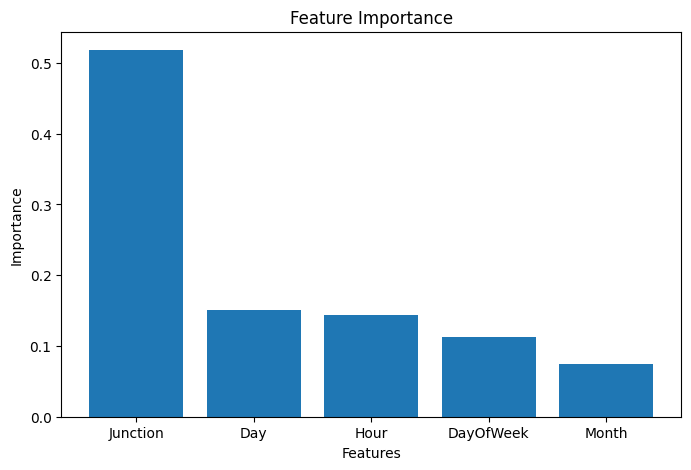

In [24]:
plt.figure(figsize=(8,5))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


Conclusion:
The machine learning model successfully predicts traffic volume using historical date-time data. The Random Forest Regressor captured traffic patterns based on hour, day, and junction. The model can be used for smart traffic management and congestion analysis.


In [25]:

junction = int(input("Enter Junction number (1-4): "))
hour = int(input("Enter Hour (0-23): "))
day = int(input("Enter Day (1-31): "))
month = int(input("Enter Month (1-12): "))
dayofweek = int(input("Enter Day of Week (0=Mon, 6=Sun): "))

sample_input = pd.DataFrame({
    'Junction': [junction],
    'Hour': [hour],
    'Day': [day],
    'Month': [month],
    'DayOfWeek': [dayofweek]
})

prediction = model.predict(sample_input)

print("\n🚦 Predicted Vehicles:", round(prediction[0]))


Enter Junction number (1-4): 2
Enter Hour (0-23): 5
Enter Day (1-31): 17
Enter Month (1-12): 10
Enter Day of Week (0=Mon, 6=Sun): 4

🚦 Predicted Vehicles: 10
